# __EXPLORATORY DATA ANALYSIS OF SUPPLYCHAIN DATASET USING MOSTLY PLOTLY__


### 1. Import necessary libraries for both data cleaning and visualization


In [1]:
#import libraries
import pandas as pd
from datetime import datetime
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.templates
import plotly.offline as py
from plotly.figure_factory import create_table

In [2]:
import os
os.listdir('/kaggle/input')

['supply-chain-management-for-car']

In [3]:
#loading csv file

data = pd.read_csv('/kaggle/input/supply-chain-management-for-car/Car_SupplyChainManagementDataSet.csv')

In [4]:
#the first 10 rows of the dataset
data.head(10)

,SupplierID,SupplierAddress,SupplierName,SupplierContactDetails,ProductID,CarMaker,CarModel,CarColor,CarModelYear,CarPrice,...,ShipDate,ShipMode,Shipping,PostalCode,Sales,Quantity,Discount,CreditCardType,CreditCard,CustomerFeedback
0,1,542 Dayton Center,Bubbletube,871-57-6028,8893,Dodge,Ram 2500,Goldenrod,2007,521963.45,...,2019/03/14,Standard Class,Truck,99522,744796.41,1,0.83,diners-club-carte-blanche,30408016042565,Bad
1,2,0674 Springview Circle,Tagopia,337-64-4060,9444,Toyota,Tundra,Crimson,2010,672222.04,...,2019/03/06,Standard Class,Truck,56398,794773.17,1,0.79,jcb,3549221112237767,Good
2,3,70 Autumn Leaf Center,Zoomdog,218-19-1802,253,GMC,Savana 1500,Crimson,2011,504465.72,...,2019/01/20,Second Class,Air,60674,968244.90,1,0.28,jcb,3557159608180902,Okay
3,4,649 Corben Lane,Oozz,635-15-3112,1283,Volkswagen,Cabriolet,Fuscia,1990,646077.11,...,2019/03/16,First Class,Truck,32885,942213.82,2,0.76,jcb,3529909223663921,Very Bad
4,5,94 Namekagon Point,Kare,849-23-6788,8905,Mercury,Mariner,Teal,2009,699890.24,...,2019/01/29,Second Class,Air,48232,879519.57,1,0.50,china-unionpay,5602235978541517,Bad
5,6,46347 Dunning Drive,Rhynyx,378-57-0118,8877,Toyota,Land Cruiser,Crimson,2005,694373.94,...,2019/03/24,Standard Class,Air,31136,947785.40,2,0.39,laser,6706247841149207,Good
6,7,85 Coleman Parkway,Roombo,479-97-2408,101,Subaru,Impreza,Indigo,1999,546977.55,...,2019/01/24,Same Day,Truck,2208,883836.81,2,0.79,diners-club-carte-blanche,30528106894581,Very Bad
7,8,30230 Westerfield Pass,Wordify,371-69-6870,8854,BMW,X6,Purple,2013,528353.80,...,2019/01/01,Second Class,Truck,25336,779626.29,1,0.90,jcb,3589144247894735,Bad
8,9,4 Coleman Street,Skyvu,717-19-7839,9043,Mitsubishi,Galant,Orange,2011,706964.35,...,2019/01/16,First Class,Air,85035,818364.32,2,0.50,jcb,3557048508901444,Okay
9,10,100 Anhalt Place,Feedfire,634-55-4653,492,Subaru,Justy,Crimson,1988,798573.59,...,2019/02/24,Standard Class,Truck,95113,902866.47,1,0.61,jcb,3534727482148019,Very Bad


In [5]:
#to understand the shape of the data
data.shape

(1000, 33)

*Data set is made up <br>1000 rows and 33 columns*

In [6]:
#transpose to view all the columns and understand dataset
data.transpose()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
SupplierID,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
SupplierAddress,542 Dayton Center,0674 Springview Circle,70 Autumn Leaf Center,649 Corben Lane,94 Namekagon Point,46347 Dunning Drive,85 Coleman Parkway,30230 Westerfield Pass,4 Coleman Street,100 Anhalt Place,...,48 Melody Parkway,6 Carioca Trail,59 Hollow Ridge Circle,56 Jay Terrace,7 Raven Way,13 Dunning Alley,60 Fairview Hill,026 Calypso Pass,73343 Oriole Court,8006 Dennis Plaza
SupplierName,Bubbletube,Tagopia,Zoomdog,Oozz,Kare,Rhynyx,Roombo,Wordify,Skyvu,Feedfire,...,Devpoint,Vidoo,Yombu,Zoovu,Devpoint,Edgeify,Zooveo,Geba,Janyx,Meembee
SupplierContactDetails,871-57-6028,337-64-4060,218-19-1802,635-15-3112,849-23-6788,378-57-0118,479-97-2408,371-69-6870,717-19-7839,634-55-4653,...,306-69-8866,159-34-3380,651-38-3577,742-59-6791,699-53-1590,352-07-3630,788-64-6027,439-17-9977,898-97-6903,544-94-3877
ProductID,8893,9444,253,1283,8905,8877,101,8854,9043,492,...,4254,3598,5110,9656,294,7534,7982,8051,7072,9722
CarMaker,Dodge,Toyota,GMC,Volkswagen,Mercury,Toyota,Subaru,BMW,Mitsubishi,Subaru,...,BMW,Mercury,Dodge,BMW,Mercury,Chevrolet,Subaru,Audi,Mazda,Oldsmobile
CarModel,Ram 2500,Tundra,Savana 1500,Cabriolet,Mariner,Land Cruiser,Impreza,X6,Galant,Justy,...,760,Sable,Durango,Z3,Lynx,Monte Carlo,Outback,Q7,B-Series,88
CarColor,Goldenrod,Crimson,Crimson,Fuscia,Teal,Crimson,Indigo,Purple,Orange,Crimson,...,Orange,Khaki,Yellow,Khaki,Khaki,Fuscia,Khaki,Green,Khaki,Goldenrod
CarModelYear,2007,2010,2011,1990,2009,2005,1999,2013,2011,1988,...,2006,1996,2005,1999,1985,2004,2006,2012,2006,1995
CarPrice,521963.45,672222.04,504465.72,646077.11,699890.24,694373.94,546977.55,528353.8,706964.35,798573.59,...,772366.39,562701.11,587045.78,734175.16,710759.09,718778.77,689650.37,525136.96,719917.26,655522.91



### 2. Deidentification of dataset



1. SupplierAddress,  
2. SupplierContactDetails,
3. CarColor	, 
4. CustomerName, 
5. PhoneNumber, 
6. JobTitle, 
7. EmailAddress, 
8. Country, 
9. PostalCode, 
10. CreditCardType, 
11. CreditCard	




In [7]:
#deidentification of dataset so as to remove information that are not important
' the customer information need to be removed which is a good practice '

df=data.drop(['SupplierAddress', 'SupplierContactDetails', 'CarColor', 'CustomerName', 'PhoneNumber', 'JobTitle', 'EmailAddress', 'Country', 'PostalCode', 'CreditCardType', 'CreditCard', 'CustomerAddress'], axis= 'columns')

In [8]:
#transpose data to view more
df.transpose()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
SupplierID,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
SupplierName,Bubbletube,Tagopia,Zoomdog,Oozz,Kare,Rhynyx,Roombo,Wordify,Skyvu,Feedfire,...,Devpoint,Vidoo,Yombu,Zoovu,Devpoint,Edgeify,Zooveo,Geba,Janyx,Meembee
ProductID,8893,9444,253,1283,8905,8877,101,8854,9043,492,...,4254,3598,5110,9656,294,7534,7982,8051,7072,9722
CarMaker,Dodge,Toyota,GMC,Volkswagen,Mercury,Toyota,Subaru,BMW,Mitsubishi,Subaru,...,BMW,Mercury,Dodge,BMW,Mercury,Chevrolet,Subaru,Audi,Mazda,Oldsmobile
CarModel,Ram 2500,Tundra,Savana 1500,Cabriolet,Mariner,Land Cruiser,Impreza,X6,Galant,Justy,...,760,Sable,Durango,Z3,Lynx,Monte Carlo,Outback,Q7,B-Series,88
CarModelYear,2007,2010,2011,1990,2009,2005,1999,2013,2011,1988,...,2006,1996,2005,1999,1985,2004,2006,2012,2006,1995
CarPrice,521963.45,672222.04,504465.72,646077.11,699890.24,694373.94,546977.55,528353.8,706964.35,798573.59,...,772366.39,562701.11,587045.78,734175.16,710759.09,718778.77,689650.37,525136.96,719917.26,655522.91
CustomerID,60760-224,67457-594,58411-135,0591-5307,51655-189,65811-0001,31722-328,54162-018,44911-0060,54868-5732,...,36987-2288,48951-3141,64735-050,36987-1348,52549-4118,0268-0030,11559-729,55143-011,0555-1054,49778-001
Gender,Male,Male,Male,Male,Female,Male,Male,Female,Female,Male,...,Female,Female,Female,Female,Female,Male,Male,Female,Female,Male
City,Anchorage,Saint Cloud,Chicago,Orlando,Detroit,Atlanta,Boston,Charleston,Phoenix,San Jose,...,Baltimore,South Bend,Gadsden,Wilmington,Sacramento,Lincoln,Salt Lake City,Tulsa,Washington,Ogden


In [9]:
#no of rows dropped
no_rows_dropped = len(data.axes[1])-len(df.axes[1])

print("we dropped  " + str(no_rows_dropped) +  " rows")

we dropped  12 rows


In [10]:
df.transpose()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
SupplierID,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
SupplierName,Bubbletube,Tagopia,Zoomdog,Oozz,Kare,Rhynyx,Roombo,Wordify,Skyvu,Feedfire,...,Devpoint,Vidoo,Yombu,Zoovu,Devpoint,Edgeify,Zooveo,Geba,Janyx,Meembee
ProductID,8893,9444,253,1283,8905,8877,101,8854,9043,492,...,4254,3598,5110,9656,294,7534,7982,8051,7072,9722
CarMaker,Dodge,Toyota,GMC,Volkswagen,Mercury,Toyota,Subaru,BMW,Mitsubishi,Subaru,...,BMW,Mercury,Dodge,BMW,Mercury,Chevrolet,Subaru,Audi,Mazda,Oldsmobile
CarModel,Ram 2500,Tundra,Savana 1500,Cabriolet,Mariner,Land Cruiser,Impreza,X6,Galant,Justy,...,760,Sable,Durango,Z3,Lynx,Monte Carlo,Outback,Q7,B-Series,88
CarModelYear,2007,2010,2011,1990,2009,2005,1999,2013,2011,1988,...,2006,1996,2005,1999,1985,2004,2006,2012,2006,1995
CarPrice,521963.45,672222.04,504465.72,646077.11,699890.24,694373.94,546977.55,528353.8,706964.35,798573.59,...,772366.39,562701.11,587045.78,734175.16,710759.09,718778.77,689650.37,525136.96,719917.26,655522.91
CustomerID,60760-224,67457-594,58411-135,0591-5307,51655-189,65811-0001,31722-328,54162-018,44911-0060,54868-5732,...,36987-2288,48951-3141,64735-050,36987-1348,52549-4118,0268-0030,11559-729,55143-011,0555-1054,49778-001
Gender,Male,Male,Male,Male,Female,Male,Male,Female,Female,Male,...,Female,Female,Female,Female,Female,Male,Male,Female,Female,Male
City,Anchorage,Saint Cloud,Chicago,Orlando,Detroit,Atlanta,Boston,Charleston,Phoenix,San Jose,...,Baltimore,South Bend,Gadsden,Wilmington,Sacramento,Lincoln,Salt Lake City,Tulsa,Washington,Ogden


In [11]:
#converting orderdate and shipdate from object to date time datatypes
df['OrderDate'] =pd.to_datetime(df.OrderDate)
df['ShipDate'] =pd.to_datetime(df.ShipDate)

In [12]:
#DATA types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   SupplierID        1000 non-null   int64         
 1   SupplierName      1000 non-null   object        
 2   ProductID         1000 non-null   int64         
 3   CarMaker          1000 non-null   object        
 4   CarModel          1000 non-null   object        
 5   CarModelYear      1000 non-null   int64         
 6   CarPrice          1000 non-null   float64       
 7   CustomerID        1000 non-null   object        
 8   Gender            1000 non-null   object        
 9   City              1000 non-null   object        
 10  CountryCode       1000 non-null   object        
 11  State             1000 non-null   object        
 12  OrderDate         1000 non-null   datetime64[ns]
 13  OrderID           1000 non-null   object        
 14  ShipDate          1000 no

_Observation_

Order date and  shipdate need to be converted to date time functions

The orderID and ShipDate are objects data types and we need to convert to datetime later for more information

In [13]:
df["DateBetweenOrder"] = df.ShipDate-df.OrderDate

In [14]:
#to check for null values
df.isna()

,SupplierID,SupplierName,ProductID,CarMaker,CarModel,CarModelYear,CarPrice,CustomerID,Gender,City,...,OrderDate,OrderID,ShipDate,ShipMode,Shipping,Sales,Quantity,Discount,CustomerFeedback,DateBetweenOrder
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


No null values
<div class="alert alert-block alert-success">
<b>Null Values:</b> No null value detected
</div>

In [15]:
df.tail(10)

,SupplierID,SupplierName,ProductID,CarMaker,CarModel,CarModelYear,CarPrice,CustomerID,Gender,City,...,OrderDate,OrderID,ShipDate,ShipMode,Shipping,Sales,Quantity,Discount,CustomerFeedback,DateBetweenOrder
990,991,Devpoint,4254,BMW,760,2006,772366.39,36987-2288,Female,Baltimore,...,2018-09-11,60505-0166,2019-05-31,Second Class,Air,752901.10,2,0.39,Very Good,262 days
991,992,Vidoo,3598,Mercury,Sable,1996,562701.11,48951-3141,Female,South Bend,...,2018-11-30,0548-3015,2019-06-06,Standard Class,Air,885826.68,1,0.78,Very Bad,188 days
992,993,Yombu,5110,Dodge,Durango,2005,587045.78,64735-050,Female,Gadsden,...,2018-09-19,49517-0001,2019-03-12,First Class,Air,874705.48,2,0.32,Okay,174 days
993,994,Zoovu,9656,BMW,Z3,1999,734175.16,36987-1348,Female,Wilmington,...,2019-05-07,0517-0725,2019-05-19,First Class,Truck,914193.62,1,0.42,Very Good,12 days
994,995,Devpoint,294,Mercury,Lynx,1985,710759.09,52549-4118,Female,Sacramento,...,2018-07-26,0703-4852,2019-03-31,Same Day,Truck,852889.61,1,0.55,Okay,248 days
995,996,Edgeify,7534,Chevrolet,Monte Carlo,2004,718778.77,0268-0030,Male,Lincoln,...,2018-08-14,68788-0046,2019-03-16,Second Class,Truck,900610.31,2,0.59,Okay,214 days
996,997,Zooveo,7982,Subaru,Outback,2006,689650.37,11559-729,Male,Salt Lake City,...,2018-09-18,36987-3015,2019-04-08,Standard Class,Air,987645.58,1,0.33,Okay,202 days
997,998,Geba,8051,Audi,Q7,2012,525136.96,55143-011,Female,Tulsa,...,2018-06-25,68180-181,2019-01-25,Second Class,Air,870962.70,2,0.25,Okay,214 days
998,999,Janyx,7072,Mazda,B-Series,2006,719917.26,0555-1054,Female,Washington,...,2019-03-10,0641-6073,2019-02-21,First Class,Air,778839.18,1,0.78,Very Bad,-17 days
999,1000,Meembee,9722,Oldsmobile,88,1995,655522.91,49778-001,Male,Ogden,...,2018-08-28,17856-5180,2019-05-04,Standard Class,Truck,821678.46,1,0.89,Very Bad,249 days


In [16]:
df.transpose()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
SupplierID,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
SupplierName,Bubbletube,Tagopia,Zoomdog,Oozz,Kare,Rhynyx,Roombo,Wordify,Skyvu,Feedfire,...,Devpoint,Vidoo,Yombu,Zoovu,Devpoint,Edgeify,Zooveo,Geba,Janyx,Meembee
ProductID,8893,9444,253,1283,8905,8877,101,8854,9043,492,...,4254,3598,5110,9656,294,7534,7982,8051,7072,9722
CarMaker,Dodge,Toyota,GMC,Volkswagen,Mercury,Toyota,Subaru,BMW,Mitsubishi,Subaru,...,BMW,Mercury,Dodge,BMW,Mercury,Chevrolet,Subaru,Audi,Mazda,Oldsmobile
CarModel,Ram 2500,Tundra,Savana 1500,Cabriolet,Mariner,Land Cruiser,Impreza,X6,Galant,Justy,...,760,Sable,Durango,Z3,Lynx,Monte Carlo,Outback,Q7,B-Series,88
CarModelYear,2007,2010,2011,1990,2009,2005,1999,2013,2011,1988,...,2006,1996,2005,1999,1985,2004,2006,2012,2006,1995
CarPrice,521963.45,672222.04,504465.72,646077.11,699890.24,694373.94,546977.55,528353.8,706964.35,798573.59,...,772366.39,562701.11,587045.78,734175.16,710759.09,718778.77,689650.37,525136.96,719917.26,655522.91
CustomerID,60760-224,67457-594,58411-135,0591-5307,51655-189,65811-0001,31722-328,54162-018,44911-0060,54868-5732,...,36987-2288,48951-3141,64735-050,36987-1348,52549-4118,0268-0030,11559-729,55143-011,0555-1054,49778-001
Gender,Male,Male,Male,Male,Female,Male,Male,Female,Female,Male,...,Female,Female,Female,Female,Female,Male,Male,Female,Female,Male
City,Anchorage,Saint Cloud,Chicago,Orlando,Detroit,Atlanta,Boston,Charleston,Phoenix,San Jose,...,Baltimore,South Bend,Gadsden,Wilmington,Sacramento,Lincoln,Salt Lake City,Tulsa,Washington,Ogden


In [17]:
# to obtain information on columns with numeric values
df.describe()

,SupplierID,ProductID,CarModelYear,CarPrice,Sales,Quantity,Discount,DateBetweenOrder
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,500.500000,5376.06400,2000.281000,649092.193460,853098.713020,1.512000,0.577360,90 days 06:41:45.600000
std,288.819436,3217.91006,9.149741,85427.262753,88538.571965,0.500106,0.187478,112 days 10:31:46.896192368
min,1.000000,3.00000,1953.000000,500412.460000,700321.490000,1.000000,0.250000,-163 days +00:00:00
25%,250.750000,2619.50000,1994.000000,572393.805000,775655.062500,1.000000,0.410000,1 days 18:00:00
50%,500.500000,5544.00000,2002.000000,654965.000000,858117.980000,2.000000,0.580000,83 days 12:00:00
75%,750.250000,8380.25000,2008.000000,721050.725000,932854.565000,2.000000,0.740000,179 days 00:00:00
max,1000.000000,9991.00000,2013.000000,799454.240000,999315.690000,2.000000,0.900000,345 days 00:00:00


In [18]:
# Create a function that we can re-use
def show_distribution(var_data):
    '''
    This function will make a distribution (graph) and display it
    '''

    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Plot the histogram   
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')

    # Add lines for the mean, median, and mode
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Plot the boxplot   
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')

    # Add a title to the Figure
    fig.suptitle('Data Distribution')

    # Show the figure
    fig.show()




Minimum:0.25
Mean:0.58
Median:0.58
Mode:0.36
Maximum:0.90



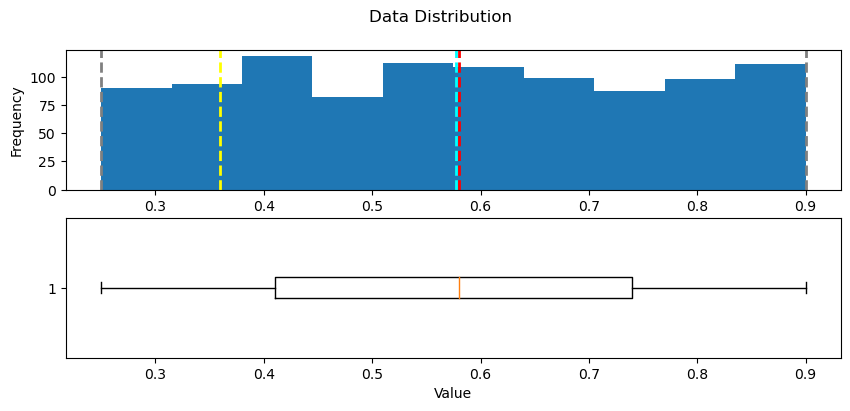

In [19]:
show_distribution(df['Discount'])

Minimum:700321.49
Mean:853098.71
Median:858117.98
Mode:700321.49
Maximum:999315.69



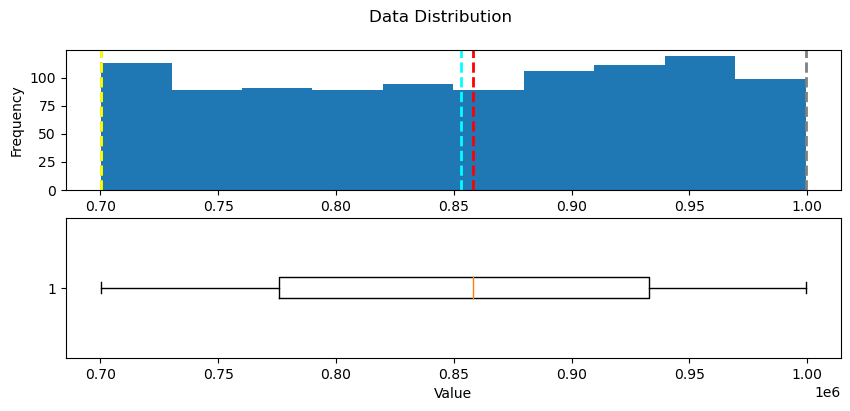

In [20]:
show_distribution(df['Sales'])

Minimum:1953.00
Mean:2000.28
Median:2002.00
Mode:2009.00
Maximum:2013.00



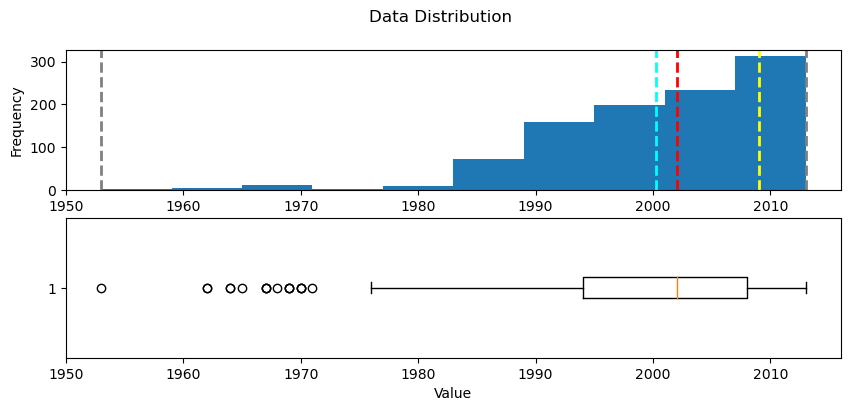

In [21]:
show_distribution(df['CarModelYear'])

<div class="alert alert-block alert-info">
<b>Tip:</b> The box-plot shows that car models below 197X are Outliers, very few of them are in the data set.
</div>

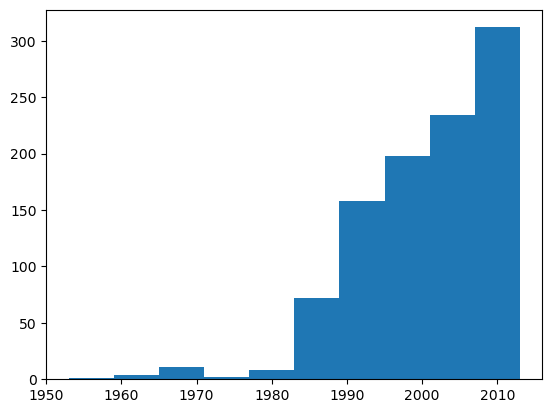

In [22]:
plt.hist(df['CarModelYear']);

Minimum:500412.46
Mean:649092.19
Median:654965.00
Mode:500412.46
Maximum:799454.24



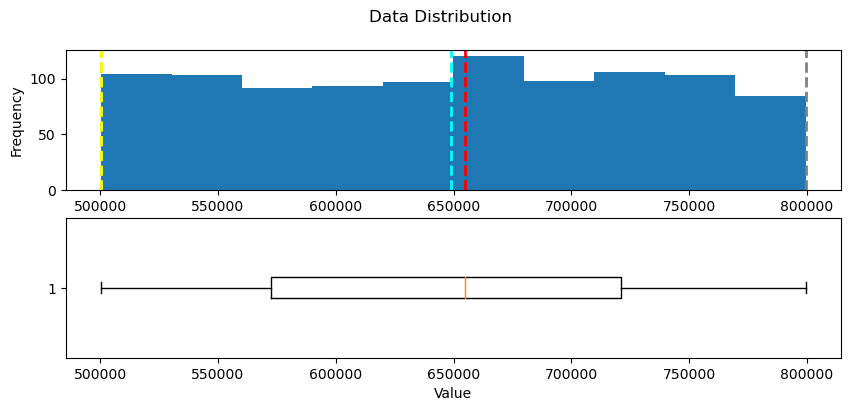

In [23]:
show_distribution(df['CarPrice'])

<div class="alert alert-block alert-info">
<b>Tip:</b> Read up articles on box-plot.
</div>

# EXPLORATORY DATA  ANALYSIS BEGINS



### 3. EDA questions 

1. Which supplier made the most sale and how much did they make?
2. which car was the most sold?
3. which supplier and car had the worst feed back and the best feed back?
4. space between order date and ship date
5. Relationship between shipmode and feedback
6. males and carmodel choice
7. females and car model choice
8. state with the highest shipment



### **853M was generated from sales**

In [24]:
#total revenue generated from car sales
df["Sales"].sum()

853098713.02

<div class="alert alert-block alert-info">
<b>SALES:</b> Sum of sales = 853098713.02 .
</div>

In [25]:
#total price of cars listed
df.CarPrice.sum()

649092193.4599999

<div class="alert alert-block alert-info">
<b>CAR PRICE:</b> Sum of Car Price = 649092193.4599999 .
</div>

## CITY AND CUSTOMER REPORTS

### Which gender purchased more cars?

In [26]:
#to count the number of males and females
df['Gender'].value_counts()

Female    502
Male      498
Name: Gender, dtype: int64


<div class="alert alert-block alert-info">
<b>TIP:</b> We have more females than males .
</div>

In [27]:
#histogram plot 
fig = px.histogram(df, x = "Gender",  color = "Quantity",
             height = 400,  template='plotly_dark')

fig.update_layout(
    title_text='A countplot of Gender of Customers', # title of plot
    #xaxis_title_text=, # xaxis label
    #yaxis_title_text=, # yaxis label
    #bargap=0.2, # gap between bars of adjacent location coordinates
    #bargroupgap=0.1 # gap between bars of the same location coordinates
)
fig.show()

<div class="alert alert-block alert-info">
<b>TIP:</b> On close obervation, a y-label was not specified in the code. Hence, the plot is just like a COUNTPLOT <br> It gives account of the number of times male or female occured in the date set and also information on how many times each mention corresponded with purchase of 2 cars or 1 car. Note that this is possible by including "color: quantity" .
</div>

In [28]:
#using groupby function to obtain the quantity of vehicles purchased by gender and the total amount of money spent
df.groupby('Gender')[["Quantity", "Sales"]].sum()

,Quantity,Sales
Gender,,
Female,760,4.273953e+08
Male,752,4.257034e+08


<div class="alert alert-block alert-info">
<b>Tip:</b> Females bought more cars than the Males.
</div>

In [29]:
# a histogram plot on the to better illustrate the information above
fig = px.histogram(df, x = "Gender", y = "Quantity", color = "Quantity", labels = {'Quantity':  " Cars purchased"},
             height = 400, template='plotly_dark', text_auto = True)#, barmode = 'group')
fig.update_layout(
    title_text='A Histogram Plot Showing Quantity of Cars Purchased By Customers', # title of plot
    #xaxis_title_text=, # xaxis label
    #yaxis_title_text=, # yaxis label
    #bargap=0.2, # gap between bars of adjacent location coordinates
    #bargroupgap=0.1 # gap between bars of the same location coordinates
)
fig.show()

In [30]:
# a histogram plot on the to better illustrate the information above
fig = px.histogram(df, x = "Gender", y = "Sales", color = "Quantity", labels = {'Sales': "Money spent"},
             height = 400, template='plotly_dark')
fig.update_layout(
    title_text='Histogram Plot Showing the Sum of Sales from Customers according to Gender', # title of plot
 
)
fig.show()

## Which city purchased more cars and generated more sales?

In [31]:
df.City.value_counts()

Washington        35
New York City     27
El Paso           18
San Antonio       15
Houston           14
                  ..
Fullerton          1
Cheyenne           1
Ridgely            1
Conroe             1
Crawfordsville     1
Name: City, Length: 300, dtype: int64


<div class="alert alert-block alert-info">
<b>Tip:</b> we have 300 unique cities.
</div>

In [32]:
df.City.value_counts().head(50)

Washington          35
New York City       27
El Paso             18
San Antonio         15
Houston             14
New Orleans         12
Sacramento          12
Seattle             12
Dallas              11
Chicago             11
Phoenix             11
Kansas City         11
Birmingham          11
Springfield         10
Atlanta             10
Denver              10
Las Vegas           10
Oklahoma City        9
Los Angeles          9
Tampa                9
Jacksonville         9
Charlotte            9
Pittsburgh           9
Des Moines           8
Austin               8
Memphis              8
Anchorage            8
Tucson               8
Clearwater           7
Charleston           7
Montgomery           7
Salt Lake City       7
San Francisco        7
Cincinnati           7
Pasadena             7
Minneapolis          7
Orlando              7
Colorado Springs     7
Saint Louis          7
Saint Petersburg     6
Buffalo              6
Dayton               6
Boise                6
Topeka     

In [33]:
#top 10 cities by sales
df.groupby('City')[["Quantity", "Sales"]].sum().sort_values(by = 'Sales', ascending = False ).head(10)

,Quantity,Sales
City,,
Washington,56,30133893.40
New York City,40,23083695.96
El Paso,24,15046728.71
San Antonio,21,13000637.65
Houston,19,11591805.67
Seattle,17,10569292.44
Sacramento,18,10231708.11
Chicago,16,10006648.28
New Orleans,15,9904902.38


In [34]:
#top 10 cities by quantity
df.groupby('City')[["Quantity", "Sales"]].sum().sort_values(by = 'Quantity', ascending = False).head(10)

,Quantity,Sales
City,,
Washington,56,30133893.40
New York City,40,23083695.96
El Paso,24,15046728.71
San Antonio,21,13000637.65
Dallas,19,9053481.82
Houston,19,11591805.67
Sacramento,18,10231708.11
Phoenix,17,9061325.67
Seattle,17,10569292.44


<div class="alert alert-block alert-info">
<b>Tip:</b> Although customers in Dallas and Houston bought 19 cars, the sum of sales from Houston customers placed them in top 5

</div>

In [35]:
# a histogram plot to show money made from cities
fig = px.histogram(df, x = "City", y = "Sales", labels = {'Sales': "Money Spent "}
                   , template='plotly_dark', height = 400)#.update_xaxes(categoryorder='total descending')
fig.update_layout(
    title_text='Money made from Cities', # title of plot
    #xaxis_title_text=, # xaxis label
    #yaxis_title_text=, # yaxis label
    #bargap=0.2, # gap between bars of adjacent location coordinates
    #bargroupgap=0.1 # gap between bars of the same location coordinates
)
fig.show()

<div class="alert alert-block alert-warning">
<b>ATTENTION:</b> When you remove the # on the code above this plot. it would arrange it in a descending order.
</div>

In [36]:
# the plot below uses the range_x lable to show just from 0 to 50 cities of the plot above
fig = px.histogram(df, x = "City", y = "Sales",hover_data = ["Quantity"] ,
                   range_x = [0,50], labels = {'Sales': "Money spent"}
                   , template='plotly_dark')
fig.show()

In [37]:
# # the plot below uses the range_y label to show sales between 15000000 - 40000000 of the plot above
fig = px.histogram(df, x = "City", y = "Sales",hover_data = ["Quantity"] ,range_x = [0,50],range_y = [15000000,40000000], labels = {'Sales': "Money spent"}
                   , template='plotly_dark')
fig.show()

<div class="alert alert-block alert-info">
<b>INFO:</b> Only Washington and New York City sold above 15million dollars.
</div>

In [38]:
fig = px.histogram(df, x = "City", y = "Quantity", labels = {'Quantity': "Cars purchased"}
                   , template='plotly_dark', height = 400)#.update_xaxes(categoryorder='total descending')
fig.update_layout(
    title_text='Number of cars purchased by cities', # title of plot
    #xaxis_title_text=, # xaxis label
    #yaxis_title_text=, # yaxis label
    #bargap=0.2, # gap between bars of adjacent location coordinates
    #bargroupgap=0.1 # gap between bars of the same location coordinates
)
fig.show()

<div class="alert alert-block alert-info">
<b>INFO:</b> Customers in  Washington and New York City bought more cars than customers all other cities.
</div>

In [39]:
#using the range_x label to view more clearly just the first 50 cities in the plot above
fig = px.histogram(df, x = "City", y = "Quantity",hover_data = ["Sales"] ,
                   range_x = [0,50],labels = {'Quantity': "Cars purchased"}
                   , template='plotly_dark')
fig.show()

## Supplier Analysis and report

In [40]:
print(df['SupplierName'].value_counts().agg('count'))

362


<div class="alert alert-block alert-info">
<b>INFO:</b> There are 362 suppliers on the dataset.
</div>

In [41]:
#analysing which supplier sold the highest quantity of cars
table = create_table(df.groupby(["SupplierName"])[[ "CarPrice","Sales","Quantity"]].sum().
                     sort_values(by = 'Quantity', ascending = False).head(30), index = True, index_title='Name of Suppliers')
py.iplot(table)

In [42]:
fig = px.histogram(df, x = "SupplierName", y = "Quantity" ,
                   labels = {'Quantity': "Cars purchased"}
                   , template='plotly_dark')#.update_xaxes(categoryorder='total ascending')
fig.update_layout(
    title_text='Number of Cars Sold by Each supplier')
fig.show()

In [43]:
fig = px.bar(df, x = "SupplierName", y = "Quantity",hover_data = ["Sales"]  ,range_x = [0,50], hover_name = "CarMaker",
                   labels = {'Quantity': "Cars purchased"}
                   , template='plotly_dark')#.update_xaxes(categoryorder='total ascending')
fig.update_layout(
    title_text='Quantity of Cars by  First 50 Suppliers')
fig.show()

In [44]:
#analysing which supplier had the highest amount of money from car sales
table2 = create_table(df.groupby(["SupplierName"])[["Quantity", "CarPrice","Sales"]].sum().
sort_values(by = 'Sales', ascending = False).head(30), index = True, index_title='Name of Suppliers')
py.iplot(table2)

In [45]:
fig = px.histogram(df, x = "SupplierName", y = "Sales" 
                   
                   , template='plotly_dark')#.update_xaxes(categoryorder='total ascending')
fig.update_layout(
    title_text='Sum of Sales by Supplier')
fig.show()

In [46]:
#using the text auto parameter to show the amount of sales in each bar
fig = px.bar(df, x = "SupplierName", y = "Sales" ,range_x = [0,50],
                   labels = {'Quantity': "Cars purchased"}
                   , template='plotly_dark', text_auto = True)#.update_xaxes(categoryorder='total ascending')
fig.update_layout(
    title_text='Sum of Sales by First 50 Supplier')
fig.show()

In [47]:
#without the text auto parameter
fig = px.bar(df, x = "SupplierName", y = "Sales" ,range_x = [0,50], hover_name = "CarMaker",
                   labels = {'Quantity': "Cars sold"}
                   , template='plotly_dark', hover_data = ['Quantity'])#, text_auto = True)#.update_xaxes(categoryorder='total ascending')
fig.show()

In [48]:
#to know the type of car sold by Kazu
df[df.SupplierName == "Kazu"].transpose()

,40,141,167,317,414,441,646,935
SupplierID,41,142,168,318,415,442,647,936
SupplierName,Kazu,Kazu,Kazu,Kazu,Kazu,Kazu,Kazu,Kazu
ProductID,7763,5285,301,4042,4685,7766,7869,9755
CarMaker,Mazda,Infiniti,Pontiac,Subaru,Cadillac,Buick,Lexus,Maybach
CarModel,Protege,EX,Montana,Impreza,Catera,Lucerne,CT,57
CarModelYear,1993,2009,2006,1996,1997,2008,2012,2005
CarPrice,623810.35,607293.44,710720.19,552478.67,517838.85,713693.94,577229.85,516753.59
CustomerID,24488-032,68220-160,76433-002,0713-0166,55154-5627,63629-1605,48951-7053,75904-3343
Gender,Female,Male,Female,Female,Male,Female,Male,Male
City,Atlanta,Washington,Waterbury,Montgomery,Honolulu,El Paso,Saint Paul,Springfield


In [49]:
Kazu_data = df.query("SupplierName == 'Kazu'")

In [50]:
Kazu_data.transpose()

,40,141,167,317,414,441,646,935
SupplierID,41,142,168,318,415,442,647,936
SupplierName,Kazu,Kazu,Kazu,Kazu,Kazu,Kazu,Kazu,Kazu
ProductID,7763,5285,301,4042,4685,7766,7869,9755
CarMaker,Mazda,Infiniti,Pontiac,Subaru,Cadillac,Buick,Lexus,Maybach
CarModel,Protege,EX,Montana,Impreza,Catera,Lucerne,CT,57
CarModelYear,1993,2009,2006,1996,1997,2008,2012,2005
CarPrice,623810.35,607293.44,710720.19,552478.67,517838.85,713693.94,577229.85,516753.59
CustomerID,24488-032,68220-160,76433-002,0713-0166,55154-5627,63629-1605,48951-7053,75904-3343
Gender,Female,Male,Female,Female,Male,Female,Male,Male
City,Atlanta,Washington,Waterbury,Montgomery,Honolulu,El Paso,Saint Paul,Springfield


In [51]:
fig = px.bar(Kazu_data, x = "CarMaker", y = "Sales", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'], template='plotly_dark')
fig.update_layout(
    title_text='Cars sold by Kazu')
fig.show()

<div class="alert alert-block alert-info">
<b>INFO:</b> Hover data parameter does not work in histogram .
</div>

In [52]:
#to know the type of car sold by Skyvu
df[df.SupplierName == "Skyvu"].transpose()

,8,325,634,751,783,930
SupplierID,9,326,635,752,784,931
SupplierName,Skyvu,Skyvu,Skyvu,Skyvu,Skyvu,Skyvu
ProductID,9043,6669,765,346,8454,8043
CarMaker,Mitsubishi,Mazda,Mazda,BMW,Buick,Saab
CarModel,Galant,626,MX-5,M3,Riviera,9-3
CarModelYear,2011,1991,2005,1999,1987,2004
CarPrice,706964.35,657876.89,783560.28,568442.22,554071.85,627014.03
CustomerID,44911-0060,98132-728,68180-750,42546-175,61919-178,68472-072
Gender,Female,Male,Female,Male,Male,Female
City,Phoenix,Montpelier,Charleston,Colorado Springs,Texarkana,Wichita Falls


In [53]:
fig = px.bar(df.query("SupplierName == 'Skyvu'"), x = "CarMaker", y = "Sales", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'], template='plotly_dark')
fig.show()

In [54]:
#to know the type of car sold by Gabcube
df[df.SupplierName == "Gabcube"].transpose()

,16,197,226,323,525,689
SupplierID,17,198,227,324,526,690
SupplierName,Gabcube,Gabcube,Gabcube,Gabcube,Gabcube,Gabcube
ProductID,7975,5903,6919,1732,8473,544
CarMaker,Mercedes-Benz,Dodge,Land Rover,Jeep,Mazda,BMW
CarModel,R-Class,Durango,Range Rover,Comanche,Miata MX-5,M6
CarModelYear,2009,2006,2001,1992,2008,2010
CarPrice,665854.24,574692.68,617676.13,538437.86,689817.44,595539.97
CustomerID,0228-2672,61667-001,67253-264,58517-340,54569-1155,0173-0772
Gender,Male,Male,Female,Female,Male,Male
City,Dayton,Flint,Montgomery,Los Angeles,Orlando,Charleston


In [55]:
fig = px.bar(df.query("SupplierName == 'Gabcube'"), x = "CarMaker", y = "Sales", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'], template='plotly_dark')
fig.show()

In [56]:
#to know the type of car sold by Quartz
df[df.SupplierName == "Quatz"].transpose()

,12,176,427,504,528,638,883
SupplierID,13,177,428,505,529,639,884
SupplierName,Quatz,Quatz,Quatz,Quatz,Quatz,Quatz,Quatz
ProductID,3334,205,4834,5029,4561,9101,8271
CarMaker,Mercedes-Benz,Isuzu,GMC,Dodge,Pontiac,Infiniti,Mitsubishi
CarModel,CL-Class,Amigo,Suburban 1500,Ram 3500,Sunfire,QX,Mighty Max Macro
CarModelYear,2011,1993,1999,1994,2004,2008,1992
CarPrice,568015.89,625746.04,787041.1,765576.5,629947.59,717562.04,746135.61
CustomerID,49825-119,68151-1471,55111-763,68258-3032,68682-004,51824-014,0280-1146
Gender,Female,Male,Female,Female,Female,Male,Male
City,Charleston,Saint Louis,Littleton,Des Moines,South Bend,Mobile,Cincinnati


In [57]:
fig = px.bar(df.query("SupplierName == 'Quatz'"), x = "CarMaker", y = "Sales", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'],  template='plotly_dark')
fig.show()

### Supplier and Feedback

### Most customers were not satisfied with their purchase

In [58]:
#analysing customer feedback
df['CustomerFeedback'].value_counts()


Bad          211
Okay         202
Very Good    201
Very Bad     200
Good         186
Name: CustomerFeedback, dtype: int64


We have a greater number of very bad and bad than good and very good

Customers that ordered two cars in one order were not satisfied with the

In [59]:
#analyzing the worst feedback #toggle between histogram and bar 
fig = px.histogram(df.query("CustomerFeedback == ['Very Bad']"), x = "SupplierName" , y = "Quantity",
             hover_name = "CustomerFeedback",
             hover_data = ['Sales'],
                   labels = {'Quantity': "Cars sold"}
                   , template='plotly_dark').update_xaxes(categoryorder='total descending')
fig.update_layout(
    title_text='Suppliers with the worst feed back')
fig.show()

In [60]:
#analyzing bad and very bad
fig = px.bar(df.query("CustomerFeedback == ['Very Bad', 'Bad']"), x = "SupplierName" , y = "Quantity",
             hover_name = "CustomerFeedback",
             hover_data = ['Sales'],
                   labels = {'Quantity': "Cars Sold"}
                   , template='plotly_dark')#, text_auto = True)#.update_xaxes(categoryorder='total ascending')
fig.update_layout(
    title_text='Suppliers with the "Bad" and "Very Bad" feed back')
fig.show()

In [61]:
fig = px.bar(df.query("CustomerFeedback == ['Very Bad']"), x = "SupplierName", y = "Sales" ,
             range_x = [0,50], hover_name = "CustomerFeedback",
             hover_data = ['Quantity'],
                   labels = {'Quantity': "Cars Sold"}
                   , template='plotly_dark')#, text_auto = True)#.update_xaxes(categoryorder='total ascending')
fig.update_layout(
    title_text='First 50 suppliers with Very bad Feedback and the Sales value')
fig.show()

In [62]:
df[df.CustomerFeedback=='Bad'].transpose()

,0,4,7,19,20,29,33,39,41,46,...,948,949,954,955,957,959,967,977,984,989
SupplierID,1,5,8,20,21,30,34,40,42,47,...,949,950,955,956,958,960,968,978,985,990
SupplierName,Bubbletube,Kare,Wordify,Yodel,Innojam,Rhyloo,Flashpoint,Quinu,Skyndu,Realbuzz,...,Quimba,Skipstorm,Fadeo,Livefish,Demimbu,Kare,Youfeed,Livetube,Voolia,Zava
ProductID,8893,8905,8854,5839,1459,4533,6551,9901,9905,983,...,3409,9945,7910,4849,8904,2271,9703,3868,8131,9043
CarMaker,Dodge,Mercury,BMW,Ford,Mercedes-Benz,Pontiac,Chevrolet,Audi,Chevrolet,Buick,...,Volvo,Mercedes-Benz,Suzuki,Dodge,Audi,Chevrolet,Kia,Lincoln,Dodge,Eagle
CarModel,Ram 2500,Mariner,X6,Tempo,SL-Class,Grand Prix,3500,100,Suburban 2500,Riviera,...,C70,CLS-Class,SJ,Ram 2500,5000S,Express 1500,Rio,MKX,Dynasty,Talon
CarModelYear,2007,2009,2013,1988,2009,1983,1996,1992,2009,1997,...,2010,2006,1985,2007,1988,2009,2013,2009,1992,1991
CarPrice,521963.45,699890.24,528353.8,686028.43,526717.03,695215.79,621482.6,518104.02,794485.02,757855.82,...,506162.39,760854.57,641960.9,798141.78,688837.92,567101.99,708205.02,789397.64,526967.62,563180.83
CustomerID,60760-224,51655-189,54162-018,49288-0606,49693-1801,69243-0610,52125-632,49938-102,11697-373,52959-997,...,66259-701,24571-111,43857-0294,37808-230,63629-1346,55926-0014,54868-6090,60681-7002,52054-215,54973-2956
Gender,Male,Female,Female,Female,Female,Female,Male,Female,Male,Male,...,Female,Male,Female,Female,Male,Female,Male,Male,Male,Female
City,Anchorage,Detroit,Charleston,Annapolis,Bloomington,Vancouver,El Paso,Battle Creek,Stockton,Spartanburg,...,Columbus,Chicago,Van Nuys,Newark,Saint Louis,Kansas City,El Paso,San Antonio,Cambridge,Saint Petersburg


## which supplier and car had the worst feed back?

### Top ten suppliers with worst feed back

In [63]:
fig = px.bar(df.query("CustomerFeedback == 'Very Bad'"), x = "SupplierName", hover_data = ['Quantity'],
             height = 400,  template='plotly_dark').update_xaxes(categoryorder='total descending')
fig.show()

In [64]:
fig = px.bar(df.query("CustomerFeedback == ['Very Bad']"), x = "SupplierName" , y = "Quantity",
             hover_name = "CustomerFeedback",
             hover_data = ['Quantity'],
                   labels = {'Quantity': "Cars sold"}
                   , template='plotly_dark')#.update_xaxes(categoryorder='total descending')
fig.show()

In [65]:
fig = px.bar(df.query("CustomerFeedback == ['Very Bad']"), x = "SupplierName" , y = "Quantity",
             hover_name = "CustomerFeedback",
             hover_data = ['Quantity'],
                   labels = {'Quantity': "Cars purchased"}
                   , template='plotly_dark', animation_frame = "SupplierName").update_xaxes(categoryorder='total descending')
fig.show()

using animation scale to animate the plot

In [66]:
#data set of everything sold by this supplier
df[df.SupplierName == "Divanoodle"].transpose()



,172,564,601,645,736,921
SupplierID,173,565,602,646,737,922
SupplierName,Divanoodle,Divanoodle,Divanoodle,Divanoodle,Divanoodle,Divanoodle
ProductID,6719,161,7091,4449,9915,6611
CarMaker,Ford,Honda,Acura,Suzuki,Ford,Ford
CarModel,Taurus,CR-V,RL,SJ,Mustang,F-Series
CarModelYear,2010,1997,2000,1985,1970,2007
CarPrice,717536.91,679745.5,774027.46,674310.63,674685.37,544872.91
CustomerID,42549-497,63730-292,68788-9164,63187-133,42924-001,75857-0001
Gender,Female,Male,Male,Female,Female,Male
City,Chicago,Texarkana,Dallas,Dayton,Anaheim,West Hartford


In [67]:
#total cars sold by this supplier
print(df[df.SupplierName =="Divanoodle"].Quantity.sum())


10


# Car brand analysis

* There are 54 unique car brands
* Chevrolet is the most sold car brand, 125 was sold and over 75m generated from its sales

In [68]:
#to obtain the car brand most sold. This gives the number 
#of times chevrolet occured in the data set
#but not the quantity of Chevrolet ordered. it is a value count
df["CarMaker"].value_counts()

Chevrolet        83
Ford             63
Toyota           52
Pontiac          50
Dodge            50
Mercedes-Benz    45
Mazda            43
Mitsubishi       41
Buick            40
GMC              37
Volkswagen       35
Nissan           31
BMW              28
Volvo            26
Audi             25
Subaru           22
Suzuki           22
Honda            19
Lexus            18
Isuzu            18
Cadillac         18
Infiniti         16
Kia              16
Lincoln          16
Mercury          15
Chrysler         14
Hyundai          14
Jaguar           13
Oldsmobile       12
Saab             11
Jeep             11
Acura            11
Land Rover       10
Plymouth          8
Lamborghini       8
Porsche           7
Maserati          6
Bentley           6
Ferrari           6
Eagle             4
Lotus             4
Geo               4
Morgan            3
Maybach           3
Scion             3
Saturn            2
Rolls-Royce       2
MINI              2
Aston Martin      2
Citroën           1


In [69]:
# number of unique car brands
df['CarMaker'].value_counts().agg('count')

54

In [70]:
df.groupby('CarMaker')[["Quantity", "Sales"]].sum()

,Quantity,Sales
CarMaker,,
Acura,16,9687663.14
Aston Martin,3,1786735.58
Audi,38,21496148.10
Austin,2,777048.56
BMW,41,23742310.09
Bentley,9,5232775.28
Buick,58,34876572.62
Cadillac,28,15278308.78
Chevrolet,125,70988582.01


In [71]:
df["CarMaker"].value_counts().tail(10)

Scion           3
Saturn          2
Rolls-Royce     2
MINI            2
Aston Martin    2
Citroën         1
MG              1
Austin          1
Daewoo          1
Ram             1
Name: CarMaker, dtype: int64

In [72]:
fig = px.histogram(df, x = "CarMaker", y = "Quantity", color = "Quantity", labels = {'Quantity: Number Sold'}, range_y = [0,100],
             height = 400, template='plotly_dark').update_xaxes(categoryorder='total descending')
fig.show()

In [73]:
fig = px.histogram(df, x = "CarMaker", y = "Sales", color = "Quantity", labels = {'Quantity: Number Sold'},
             height = 400, template='plotly_dark', animation_frame = 'Quantity').update_xaxes(categoryorder='total descending')
fig.show()

# Analyzing the most sold car -- Chevrolet

* Total sales : 7.09m
* Highest supplier: feedfish
* Model that generated highest sales: Camaro

In [74]:
df[df.CarMaker == "Chevrolet"].transpose()

,21,33,36,41,61,88,102,103,127,160,...,875,879,905,937,939,944,959,975,982,995
SupplierID,22,34,37,42,62,89,103,104,128,161,...,876,880,906,938,940,945,960,976,983,996
SupplierName,Skidoo,Flashpoint,Oyonder,Skyndu,Photojam,Omba,Realcube,Skivee,Wordify,Skipfire,...,Flashdog,Browseblab,Yakijo,Bluejam,Yodoo,Zoomdog,Kare,Eamia,Twitternation,Edgeify
ProductID,8464,6551,5911,9905,5299,4440,7023,7855,245,8499,...,4682,6511,7724,110,7759,9239,2271,9304,9396,7534
CarMaker,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,...,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet,Chevrolet
CarModel,Monte Carlo,3500,Corvette,Suburban 2500,Camaro,Suburban 1500,Sportvan G30,Express 1500,Suburban 1500,HHR,...,Caprice,Citation,Beretta,Silverado 2500,Sportvan G10,Silverado 1500,Express 1500,Express 1500,G-Series G10,Monte Carlo
CarModelYear,1996,1996,1998,2009,2010,2003,1995,2004,1997,2007,...,1977,1980,1995,2009,1993,2004,2009,2009,1994,2004
CarPrice,569743.98,621482.6,579336.1,794485.02,757579.72,714262.33,679976.16,665876.6,677203.05,754328.07,...,584013.95,754141.69,508442.61,746875.73,540825.5,611966.63,567101.99,560777.07,630469.02,718778.77
CustomerID,23155-141,52125-632,0603-1384,11697-373,53150-411,37808-008,54458-907,33261-228,49288-0302,63565-0001,...,43857-0300,55655-121,16590-987,54575-348,41520-140,63629-5094,55926-0014,49671-002,55711-070,0268-0030
Gender,Female,Male,Male,Male,Female,Male,Female,Male,Male,Female,...,Female,Female,Male,Female,Male,Male,Female,Male,Male,Male
City,Santa Monica,El Paso,Roanoke,Stockton,Detroit,Fort Smith,Olympia,Washington,Madison,Richmond,...,Wilmington,Saint Louis,Chicago,Lafayette,Las Vegas,New Haven,Kansas City,Saint Louis,Charlottesville,Lincoln


In [75]:
#amount of money made from selling chevrolet
df[df.CarMaker == "Chevrolet"].Sales.sum()

70988582.01

In [76]:
#number of chevrolet sold
df[df.CarMaker == "Chevrolet"].Quantity.sum()

125

In [77]:
#top ten suppliers of chevrolet
df[df.CarMaker == "Chevrolet"].SupplierName.value_counts().head(10)

Divavu       2
Eidel        2
Feedfish     2
Bubblemix    2
Gabvine      1
Vitz         1
Eadel        1
Meevee       1
Voomm        1
Oyoba        1
Name: SupplierName, dtype: int64

In [78]:
#underdstanding the most car chevrolet  by supplier
fig = px.bar(df.query("CarMaker == 'Chevrolet' "), x = "SupplierName",
             y = "Quantity", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'], 
             template='plotly_dark').update_xaxes(categoryorder='total descending')
fig.show()

In [79]:
#underdstanding the most car chevrolet  by supplier
fig = px.bar(df.query("CarMaker == 'Chevrolet' "), x = "SupplierName", y = "Sales",
             color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'],
             template='plotly_dark', animation_frame = 'SupplierName').update_xaxes(categoryorder='total descending')
fig.show()

In [80]:
#underdstanding the most car chevrolet by model
fig = px.histogram(df.query("CarMaker == 'Chevrolet' "), x = "CarModel", y = "Sales", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'], template='plotly_dark').update_xaxes(categoryorder='total descending')
fig.show()

## what about lamborghini?


* Total Sales: 7.02M
* Most profitable supplier: Dazzlesphere

In [81]:
#investigating lamborghini
df[df.CarMaker == "Lamborghini"].Sales.sum()

7026228.98

In [82]:
Lambo_data = df.query("CarMaker == 'Lamborghini' ")

In [83]:
Lambo_data.transpose()

,147,148,237,252,595,671,677,981
SupplierID,148,149,238,253,596,672,678,982
SupplierName,Trunyx,Dazzlesphere,Mymm,Shuffletag,Skiba,Brightbean,Linklinks,Eidel
ProductID,8964,2189,8664,8884,2104,9116,9991,7748
CarMaker,Lamborghini,Lamborghini,Lamborghini,Lamborghini,Lamborghini,Lamborghini,Lamborghini,Lamborghini
CarModel,Gallardo,Murciélago,Murciélago,Murciélago LP640,Diablo,Gallardo,Diablo,Gallardo
CarModelYear,2010,2008,2002,2008,1995,2009,1991,2003
CarPrice,642557.99,587427.52,603490.6,698779.93,639325.75,714654.98,616493.0,679404.14
CustomerID,59779-115,68151-4021,0555-1056,14783-323,50988-183,68382-112,36987-2341,63629-1468
Gender,Male,Female,Female,Male,Male,Male,Male,Male
City,Portland,Tampa,Pittsburgh,Charlotte,Spokane,Riverside,Columbus,Arlington


In [84]:
fig = px.bar(Lambo_data, x = "SupplierName", y = "Sales", color = "Quantity", labels = {'Sales': "Money made"},
             height = 400, hover_data = ['CarPrice'], template='plotly_dark').update_xaxes(categoryorder='total descending')
fig.show()

## Analysing shipmode and shipping 

In [85]:
df['ShipMode'].value_counts()

Second Class      254
Standard Class    253
First Class       250
Same Day          243
Name: ShipMode, dtype: int64

### Most cars were shipped through the second class shipmode

In [86]:
table3 = create_table(df.groupby("ShipMode")[["Quantity", "Sales"]].sum().
                      sort_values(by = "Sales", ascending = False).head(10), index  = True, index_title = 'ShipMode',
                      height_constant=30)
py.iplot(table3)

In [87]:
#get information on certain categorical values
df['Shipping'].value_counts()


Air      509
Truck    491
Name: Shipping, dtype: int64

### A greater number of cars were shipped to their owners by air

In [88]:
table3 = create_table(df.groupby("Shipping")[["Quantity", "Sales"]].sum().sort_values(by = "Sales", ascending = False).head(10), index  = True, 
                      index_title = 'Shipping',height_constant=4 )
py.iplot(table3)